# CV^2 vs Mean Plot for G1 129 and G1 CAST
This notebook loads allele count data, extracts the mean and coefficient of variation squared (CV^2) across the columns for each transcript row, and plots them.

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

def process_file(filepath):
    print(f"Loading {filepath}...")
    df = pd.read_csv(filepath, sep=' ', index_col=0)
    
    # Calculate mean and variance across the columns for each gene (row)
    # Note: in pandas, axis=1 applies the operation across columns.
    row_mean = df.mean(axis=1)
    row_var = df.var(axis=1)
    
    # Extract into a results dataframe
    extracted_df = pd.DataFrame({
        'mean': row_mean,
        'var': row_var
    })
    
    # Filter out rows with zero mean to avoid division by zero
    extracted_df = extracted_df[extracted_df['mean'] > 0].copy()
    
    # Filter out extreme outliers where mean > 10000
    extracted_df = extracted_df[extracted_df['mean'] <= 10000]
    
    # Calculate cv2 = variance / (mean ^ 2)
    extracted_df['cv2'] = extracted_df['var'] / (extracted_df['mean'] ** 2)
    
    return extracted_df


In [36]:
df_129 = process_file('data/ochiai/GSE132589_ASEcount_G1_129.txt')
df_cast = process_file('data/ochiai/GSE132589_ASEcount_G1_CAST.txt')

print(f"129: {len(df_129)} genes")
print(f"CAST: {len(df_cast)} genes")

# Display the extracted stats for the first few genes
display(df_129.head())


Loading data/ochiai/GSE132589_ASEcount_G1_129.txt...
Loading data/ochiai/GSE132589_ASEcount_G1_CAST.txt...
129: 90688 genes
CAST: 94576 genes


,mean,var,cv2
ENSMUST00000000001,51.434368,733.514223,0.277269
ENSMUST00000000010,0.033413,0.113713,101.855336
ENSMUST00000000028,18.298329,263.305524,0.786388
ENSMUST00000000033,0.579952,17.071942,50.757289
ENSMUST00000000049,0.002387,0.002387,419.000000


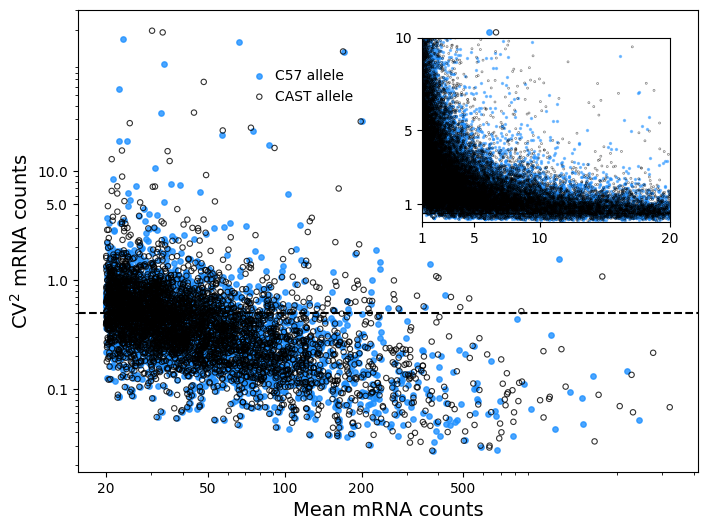

In [ ]:
fig, ax_main = plt.subplots(figsize=(8, 6))

# Main plot: mean > 20
mask_129_high = df_129['mean'] > 20
mask_cast_high = df_cast['mean'] > 20

ax_main.scatter(df_129.loc[mask_129_high, 'mean'], df_129.loc[mask_129_high, 'cv2'], alpha=0.8, label='C57 allele', color='dodgerblue', s=15)
ax_main.scatter(df_cast.loc[mask_cast_high, 'mean'], df_cast.loc[mask_cast_high, 'cv2'], alpha=0.8, label='CAST allele', facecolors='none', edgecolors='black', s=15, linewidth=0.8)

ax_main.set_xlabel('Mean mRNA counts', fontsize=14)
ax_main.set_ylabel('CV$^2$ mRNA counts', fontsize=14)
ax_main.set_xscale('log')
ax_main.set_yscale('log')
ax_main.set_xticks([20, 50, 100, 200, 500])
ax_main.get_xaxis().set_major_formatter(plt.ScalarFormatter())
ax_main.set_yticks([0.1, 1.0, 5.0, 10, 100])
ax_main.get_yaxis().set_major_formatter(plt.ScalarFormatter())
ax_main.axhline(y=0.5, color='black', linestyle='--', linewidth=1.5)

# Customize legend to match the image
ax_main.legend(loc='upper left', bbox_to_anchor=(0.25, 0.9), frameon=False, handletextpad=0.1)

# Inset plot: mean <= 20
ax_inset = inset_axes(ax_main, width="40%", height="40%", loc='upper right', borderpad=2)

mask_129_low = df_129['mean'] <= 20
mask_cast_low = df_cast['mean'] <= 20

ax_inset.scatter(df_129.loc[mask_129_low, 'mean'], df_129.loc[mask_129_low, 'cv2'], alpha=0.5, color='dodgerblue', s=2)
ax_inset.scatter(df_cast.loc[mask_cast_low, 'mean'], df_cast.loc[mask_cast_low, 'cv2'], alpha=0.5, facecolors='none', edgecolors='black', s=2, linewidth=0.5)
ax_inset.set_ylim(0, 10)
ax_inset.set_xlim(18, 20)
ax_inset.set_xticks([1, 5, 10, 20])
ax_inset.get_xaxis().set_major_formatter(plt.ScalarFormatter())
ax_inset.set_yticks([1, 5, 10])
ax_inset.get_yaxis().set_major_formatter(plt.ScalarFormatter())
ax_inset.axhline(y=0.5, color='black', linestyle='--', linewidth=1)

plt.show()
